In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/raw/smart_meter_data.csv",
    parse_dates=["timestamp"]
)

df = df.sort_values("timestamp")

In [3]:
split_point = int(len(df) * 0.7)

baseline = df.iloc[:split_point]["consumption_kwh"]
current = df.iloc[split_point:]["consumption_kwh"]

In [4]:
ks_stat, p_value = ks_2samp(baseline, current)

print(f"KS Statistic : {ks_stat:.4f}")
print(f"P-value      : {p_value:.6f}")

if p_value < 0.05:
    print("⚠️ Concept Drift Detected (Distributions differ)")
else:
    print("✅ No Significant Drift Detected")

KS Statistic : 0.1927
P-value      : 0.000000
⚠️ Concept Drift Detected (Distributions differ)


In [5]:
def calculate_psi(expected, actual, bins=10):
    breakpoints = np.linspace(0, 100, bins + 1)
    expected_perc = np.percentile(expected, breakpoints)
    actual_perc = np.percentile(actual, breakpoints)

    psi = 0
    for i in range(len(expected_perc) - 1):
        exp_pct = (
            (expected >= expected_perc[i]) &
            (expected < expected_perc[i+1])
        ).mean()

        act_pct = (
            (actual >= actual_perc[i]) &
            (actual < actual_perc[i+1])
        ).mean()

        psi += (act_pct - exp_pct) * np.log(
            (act_pct + 1e-6) / (exp_pct + 1e-6)
        )

    return psi

psi_value = calculate_psi(baseline, current)
print(f"PSI Value: {psi_value:.4f}")

PSI Value: 0.0000


In [6]:
if psi_value < 0.1:
    print("✅ No Drift")
elif psi_value < 0.25:
    print("⚠️ Moderate Drift")
else:
    print("🚨 Severe Drift – Model Retraining Required")

✅ No Drift


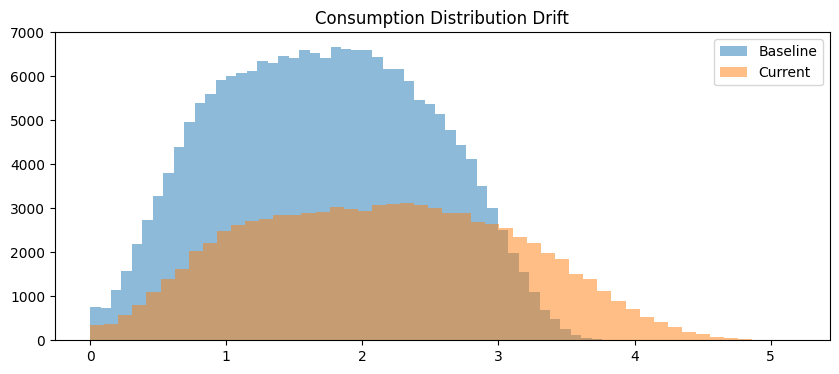

In [7]:
plt.figure(figsize=(10,4))
plt.hist(baseline, bins=50, alpha=0.5, label="Baseline")
plt.hist(current, bins=50, alpha=0.5, label="Current")
plt.legend()
plt.title("Consumption Distribution Drift")
plt.show()